<a href="https://colab.research.google.com/github/ManoGit-99/Gmapoi-Repository/blob/main/Projet_06_S%C3%A9ries_temporelles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projet 06 - Séries temporelles : combien de glaces préparer demain ?

*Temps estimé : 60 minutes*

*Difficulté : 4/10*

<div align="center">
<img src="./projet_06.png" alt="ouvrir dans VSCode pour voir l'image" width="800"/>
</div>

Tu sors de l'aquarium avec ta nièce. 🙂

Vous passez par la plage et vous vous arrêtez pour prendre une glace.

C'est là que vous faites la rencontre de Bruno, le marchand de glaces.

Il t'explique que, chaque matin, c'est le même problème : combien de bacs sortir du congélateur ?

* Trop peu, et il refuse des clients à 16 h, en pleine chaleur.
* Trop, et il doit jeter des glaces.

« Le problème, c'est que je n'ai aucune idée du nombre de clients que j'aurai. Certains jours, j'en vends 120, d'autres 270. Je dois y aller au **pif**. Toi qui es Data Scientist, tu peux m'aider ?»

Tu lui demandes s'il a noté ses ventes quelque part. Il revient avec un carnet à spirale : **le nombre de glaces vendues chaque jour depuis quatre étés**. C'est tout ce dont on a besoin.

Pas de météo, pas de nombre de touristes, pas de jours fériés : juste une colonne de nombres, dans l'ordre du temps. C'est ce qu'on appelle une **série temporelle**, et c'est l'une des spécialités des Data Scientists !

On y va !


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Les outils du jour : la famille ARMA

Dans ce projet, nous allons découvrir (ou redécouvrir) une famille de modeles qui a fait ses preuves avec le temps, les modeles d'Auto-Regression et de Moving Average : ARMA.

Ces modeles integrent 2 composantes :

- **AR** (*AutoRegressive*) : les ventes d'aujourd'hui ressemblent à celles d'hier. La série a de l'**inertie**.
- **MA** (*Moving Average*) : les ventes d'aujourd'hui gardent la trace des **surprises** des derniers jours. Une journée exceptionnellement bonne laisse un écho quelques jours (le bouche-à-oreille, les gens qui reviennent).

Attention au faux ami : le **MA** de la famille ARMA n'est PAS la moyenne mobile que tu connais peut-être avec pandas (« la moyenne des 7 derniers jours »). C'est une régression sur les **erreurs** passées, pas sur les valeurs passées. On va voir précisément ce que ça veut dire.

Assemble les deux et tu obtiens un **ARMA**. C'est le plan du projet : on commence par le MA seul, la solution la plus naturelle pour Bruno, puis on ajoute l'AR quand on aura assez de données pour le justifier.

### uv add : une librairie de plus

```bash
uv add statsmodels
```

`statsmodels`, c'est la boîte à outils des statisticiens en Python : modèles ARMA, tests d'hypothèses, corrélogrammes. Là où `scikit-learn` te donne un score, `statsmodels` te donne un tableau de résultats avec des coefficients, des écarts-types et des p-values. Je la recommande vraiment pour tous les Data Scientists qui veulent passer le cran suivant.

`utils.py` fournit comme d'habitude les affichages (`plot_ventes`, `plot_correlogrammes`, `plot_previsions`, `plot_semaine`), la métrique `mae`, et une fonction `prevision_1_jour` dont on reparlera.

In [6]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox

from utils import (mae, plot_correlogrammes, plot_previsions, plot_semaine, plot_ventes,
                   prevision_1_jour, tableau_des_scores)

np.random.seed(42)

# Partie 1 - Le carnet de Bruno

Comme énnoncé au début, Bruno t'a communiqué ses chiffres des années passées. Tu peux les trouver dans `data/ventes_glaces.csv` : une ligne par jour d'ouverture, du 1er juin au 30 septembre, pour les étés 2022 à 2025.


Premier exercice : Ouvrez le dataset avec `pandas` avec l'argument `parse_dates` (et oui.. c'est un projet sur les séries temporelles) :-)

488 jours d'ouverture, de 2022-06-01 à 2025-09-30


,date,saison,ventes
0,2022-06-01,2022,189
1,2022-06-02,2022,203
2,2022-06-03,2022,208
3,2022-06-04,2022,198
4,2022-06-05,2022,207


,mean,std,min,max
saison,,,,
2022,195.5,31.3,123,273
2023,199.7,28.9,118,262
2024,193.1,36.1,116,278
2025,199.8,35.3,120,275


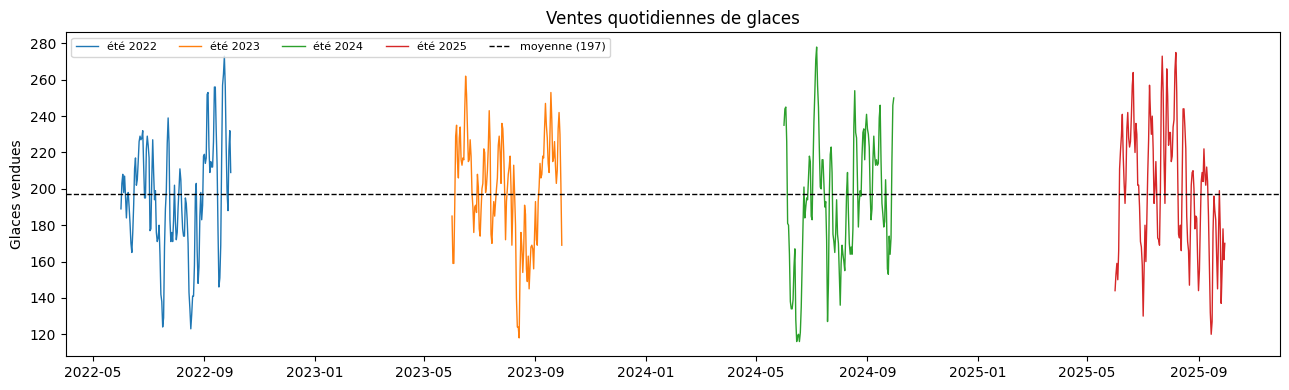

In [7]:
### START CODE HERE ###
ventes_df = pd.read_csv('/content/ventes_glaces.csv', parse_dates=['date'])
### END CODE HERE ###

print(f"{len(ventes_df)} jours d'ouverture, de {ventes_df['date'].min().date()} à {ventes_df['date'].max().date()}")
display(ventes_df.head())
display(ventes_df.groupby("saison")["ventes"].agg(["mean", "std", "min", "max"]).round(1))

plot_ventes(ventes_df)

Le graphique dit déjà l'essentiel : ça oscille beaucoup (de 116 à 278 glaces), sans tendance qui monte ni qui descend, autour d'une moyenne d'environ 197 glaces par jour. Mais ce n'est pas du bruit pur : on voit nettement des **paquets** de bonnes journées et des paquets de mauvaises. C'est cette structure qu'on va exploiter.


## Commencons par Une Baseline

Nous en avons déja parlé lors des projets précédent, en Machine Learning il faut toujours disposer d'une référence de base pour évaluer notre modele..

Ici, Bruno, nous dit qu'il a deux stratégies (tres simples) pour prévoir ses ventes :

1. **« Je prépare la moyenne »** : toujours le même nombre, quoi qu'il arrive.
2. **« Je prépare comme hier »** : la météo ne change pas du jour au lendemain, donc demain ressemblera à aujourd'hui.

### Mais pour bien évaluer ses stratégies, il convient de bien découper nos données (et surtout pas au hasard)

Une règle absolue en séries temporelles : on n'a **jamais** le droit de mélanger les jours avant de découper. Prédire le 12 août en s'étant entraîné sur le 13, c'est lire l'avenir (et donc tricher). Le score serait magnifique et le modèle inutilisable.

On garde donc les **22 derniers jours** (la fin de la saison 2025) comme période de test, et tout ce qui précède pour l'entraînement.

Exercice : Prépare les données comme convenu, et met en place les 2 stratégies de Bruno, afin de les évaluer avec la MAE (l'erreur absolue moyenne) sur les données du passé.


In [9]:
N_TEST = 22

ventes = ventes_df["ventes"].to_numpy(dtype=float)
dates = ventes_df["date"]

### START CODE HERE ###
train, test = ventes[:-N_TEST], ventes[-N_TEST:]
dates_test = dates.iloc[-N_TEST:]
### END CODE HERE ###

In [11]:
### START CODE HERE ###
baseline_moyenne = train.mean() # la moyenne des ventes
baseline_hier = ventes[-(N_TEST+1):-1] # la veille de chaque jour de test
### END CODE HERE ###

scores = {
    "Toujours la moyenne": mae(test, baseline_moyenne),
    "Comme hier": mae(test, baseline_hier),
}
for nom, valeur in scores.items():
    print(f"{nom:22s} : {valeur:.2f} glaces d'écart en moyenne")

Toujours la moyenne    : 30.38 glaces d'écart en moyenne
Comme hier             : 19.00 glaces d'écart en moyenne


Parfait, on voit ainsi que lorsque Bruno prévoit ses ventes de glaces en prenant la moyenne, il faut une erreur moyenne de 30 glaces par jour. Et quand il reprend le chiffre de hier, il fait alors une erreur de 19 glaces.

Il semblerait donc que son idée de considérer les ventes de hier pour prévoir celle du lendemain ait du sens.

Nous allons vérifier cela.

# Partie 2 - La mémoire d'une série

Comment savoir si les ventes d'aujourd'hui ont quelque chose à voir avec celles d'hier ? En calculant la corrélation de la série **avec elle-même, décalée d'un cran**. C'est l'**autocorrélation**, et c'est l'outil de base de toute l'analyse des séries temporelles.

### Étape 1 : l'autocorrélation à la main

Écris `autocorrelation(serie, lag)` : la corrélation entre la série et la même série décalée de `lag` jours. La formule est celle d'une corrélation classique, avec un décalage :

$$r_{lag} = \frac{\sum_t (y_t - \bar{y})(y_{t-lag} - \bar{y})}{\sum_t (y_t - \bar{y})^2}$$

Trois étapes :
1. calcule les écarts à la moyenne : `ecarts = serie - serie.mean()`
2. le numérateur : la somme des produits `ecarts[lag:] * ecarts[:-lag]` (les écarts d'aujourd'hui multipliés par ceux d'il y a `lag` jours)
3. le dénominateur : la somme des `ecarts ** 2`

> Indice : `ecarts[lag:]` donne les écarts à partir du jour `lag`, et `ecarts[:-lag]` les mêmes décalés en arrière. Les deux tableaux ont exactement la même longueur, tu peux les multiplier terme à terme.

In [13]:
def autocorrelation(serie, lag):
    """
    Correlation of a series with itself, shifted by lag steps.

    Arguments:
    serie -- the time series, as a 1D array
    lag -- the shift, in days (lag=1 compares each day with the day before)

    Returns:
    r -- the autocorrelation coefficient, between -1 and 1
    """
    serie = np.asarray(serie, dtype=float)

    ### START CODE HERE ###

    ecarts = serie - serie.mean() # (1) les écarts à la moyenne
    numerateur = np.sum(ecarts[lag:] * ecarts[:-lag]) # (2) produits des écarts décalés de lag
    denominateur = np.sum(ecarts ** 2) # (3) la variance totale
    r = numerateur / denominateur

    ### END CODE HERE ###

    return r

In [14]:
ventes_2025 = ventes_df.loc[ventes_df["saison"] == 2025, "ventes"].to_numpy(dtype=float)

for lag in range(1, 5):
    print(f"autocorrélation à {lag} jour(s) : {autocorrelation(ventes_2025, lag):+.3f}")

reference = acf(ventes_2025, nlags=4)
assert abs(autocorrelation(ventes_2025, 1) - reference[1]) < 1e-9, \
    "Ton résultat devrait être identique à celui de statsmodels au retard 1"
assert abs(autocorrelation(ventes_2025, 3) - reference[3]) < 1e-9, \
    "Ton résultat devrait être identique à celui de statsmodels au retard 3"
print("\nExercice validé ! Une journée ressemble énormément à la veille (r ≈ 0.81), un peu moins à l'avant-veille.")

autocorrélation à 1 jour(s) : +0.813
autocorrélation à 2 jour(s) : +0.518
autocorrélation à 3 jour(s) : +0.319
autocorrélation à 4 jour(s) : +0.164

Exercice validé ! Une journée ressemble énormément à la veille (r ≈ 0.81), un peu moins à l'avant-veille.


Empiler ces coefficients pour tous les retards donne le **corrélogramme** (ACF). À côté, on trace la **PACF**, sa cousine : elle mesure le lien direct entre aujourd'hui et il y a `k` jours, **une fois retiré** tout ce qui passe par les jours intermédiaires.

La bande bleue est la zone où une barre est indistinguable de zéro : seules celles qui en sortent portent une vraie information.

Commençons par la saison que Bruno a sortie en premier : l'été 2025.

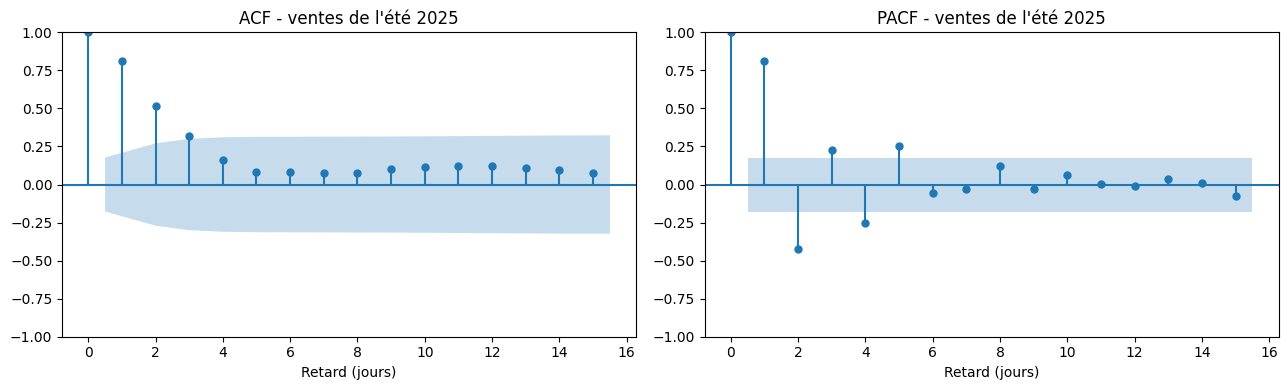

In [15]:
plot_correlogrammes(ventes_2025, lags=15, titre="- ventes de l'été 2025")

Lecture : l'ACF sort de la bande aux retards **1, 2 et 3** (le troisième de justesse), puis rentre dans le bruit. Traduction en français : *une journée influence les trois jours qui suivent, et au-delà on ne voit plus rien.*

Une mémoire courte qui s'arrête net après `q` jours, c'est exactement la signature d'un modèle **MA(q)**. On tient notre première piste : **MA(3)**.

# Partie 3 - Le modèle MA

L'idée du MA est plus simple que son nom. Chaque jour, il se passe quelque chose d'imprévisible : un orage, un car de touristes, un mariage sur la plage. Appelons ça le **choc** du jour, noté $\varepsilon_t$, la part des ventes que rien ne permettait d'anticiper.

Le modèle MA dit que les ventes du jour sont la moyenne, plus le choc du jour, plus **un écho des chocs des jours précédents** :

$$y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \theta_3 \varepsilon_{t-3}$$

Un $\theta_1$ de 0.8 veut dire : « une journée qui a dépassé les attentes de 10 glaces en ramène 8 de plus le lendemain ». Le bouche-à-oreille, mis en équation.

### Étape 2 : fabriquer une série MA à la main

Le plus sûr moyen de comprendre un modèle est de s'en servir pour **fabriquer** des données. Écris `simuler_ma(mu, thetas, chocs)` : à partir d'une liste de chocs tirés au hasard, elle applique la formule ci-dessus et retourne la série obtenue.

Pour chaque instant `t` (en commençant à `t = q`, pour avoir assez de chocs passés derrière soi) :
1. pars de `mu + chocs[t]` (la moyenne, plus le choc du jour)
2. ajoute `theta * chocs[t - i]` pour chaque `theta` numéro `i` de la liste
3. empile le résultat

> Indice : `for i, theta in enumerate(thetas, start=1):` te donne directement `i = 1, 2, 3...` en même temps que chaque `theta`, ce qui te permet d'écrire `chocs[t - i]`.

In [17]:
def simuler_ma(mu, thetas, chocs):
    """
    Build a Moving Average series from a sequence of random shocks.

    y_t = mu + eps_t + theta_1 * eps_{t-1} + ... + theta_q * eps_{t-q}

    Arguments:
    mu -- the average level of the series
    thetas -- list of q coefficients, one per past shock
    chocs -- array of random shocks, one per time step

    Returns:
    serie -- the simulated series, of length len(chocs) - q
    """
    q = len(thetas)
    serie = []

    ### START CODE HERE ###

    for t in range(q, len(chocs)):
        valeur = mu + chocs[t] # (1) la moyenne + le choc du jour
        for i, theta in enumerate(thetas, start=1):
            valeur += theta * chocs[t - i] # (2) l'écho des chocs passés
        serie.append(valeur) # (3)

    ### END CODE HERE ###

    return np.array(serie)

Testons a présent cette fonction :

In [18]:
chocs_test = np.array([0.0, 10.0, 0.0, 0.0, 0.0])
print("Un seul choc de +10 au jour 1, avec theta = [0.8, 0.4] :")
print(simuler_ma(200, [0.8, 0.4], chocs_test), "  <- l'écho s'éteint en 2 jours")

chocs = np.random.normal(0, 15, 4000)
simulee = simuler_ma(200, [0.5], chocs)
print(f"\nMA(1) simulé avec theta=0.5 : autocorrélation au retard 1 = {autocorrelation(simulee, 1):.3f}")
print(f"                              valeur théorique theta/(1+theta^2) = {0.5 / 1.25:.3f}")
print(f"                              autocorrélation au retard 2 = {autocorrelation(simulee, 2):+.3f} (nulle, comme prévu)")

assert len(simuler_ma(200, [0.8, 0.4], chocs_test)) == 3, "La série doit être plus courte que les chocs de q valeurs"
assert abs(autocorrelation(simulee, 1) - 0.4) < 0.03, "Un MA(1) de theta=0.5 doit donner r1 proche de 0.40"
assert abs(autocorrelation(simulee, 2)) < 0.03, "Un MA(1) n'a aucune mémoire au-delà du retard 1"
print("\nExercice validé ! Un MA(q) oublie tout après exactement q jours.")

Un seul choc de +10 au jour 1, avec theta = [0.8, 0.4] :
[208. 204. 200.]   <- l'écho s'éteint en 2 jours

MA(1) simulé avec theta=0.5 : autocorrélation au retard 1 = 0.385
                              valeur théorique theta/(1+theta^2) = 0.400
                              autocorrélation au retard 2 = -0.021 (nulle, comme prévu)

Exercice validé ! Un MA(q) oublie tout après exactement q jours.


Retiens bien la dernière ligne : **un MA(q) a une mémoire qui s'arrête net après `q` jours**. C'est ce qui nous a fait choisir MA(3) en regardant l'ACF, et c'est ce qui va nous limiter tout à l'heure.

### Étape 3 : ajuster le MA aux ventes de Bruno

Simuler, c'est bien ; retrouver les coefficients à partir de vraies ventes, c'est mieux. C'est le travail de `statsmodels` : on lui donne la série, l'ordre du modèle, et il cherche les $\theta$ qui collent le mieux.

L'ordre s'écrit `order=(p, d, q)` : `p` pour la partie AR, `d` pour la différenciation (on n'en a pas besoin ici), `q` pour la partie MA. Pour un MA(3) pur : `order=(0, 0, 3)`. Et `trend="c"` demande d'estimer aussi la constante $\mu$.

1. construis le modèle : `ARIMA(train_2025, order=(0, 0, 3), trend="c")`
2. ajuste-le : `.fit()`

> Indice : on peut écrire (1) et (2) sur une ligne, `resultat_ma = ARIMA(...).fit()`.

In [20]:
train_2025 = ventes_2025[:-N_TEST]   # la saison 2025, sans les 22 derniers jours

### START CODE HERE ###

resultat_ma = ARIMA(train_2025, order=(0, 0, 3), trend="c").fit()   # MA(3) : 0 terme AR, 0 différenciation, 3 termes MA

### END CODE HERE ###

print(f"mu estimé : {resultat_ma.params[0]:.1f} glaces par jour")
for i in range(1, 4):
    print(f"theta_{i}   : {resultat_ma.params[i]:+.3f}")
print(f"AIC       : {resultat_ma.aic:.1f}")

assert len(resultat_ma.params) == 5, "On attend 5 paramètres : la constante, 3 thetas, et la variance du bruit"
print("\nExercice validé ! L'écho d'une bonne journée est fort le lendemain, puis s'estompe.")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


mu estimé : 205.3 glaces par jour
theta_1   : +1.526
theta_2   : +0.784
theta_3   : +0.089
AIC       : 850.9

Exercice validé ! L'écho d'une bonne journée est fort le lendemain, puis s'estompe.


Reste la question qui intéresse Bruno : est-ce que ça prépare mieux les bacs que son pifomètre ?

On se place dans sa vraie situation : **chaque soir**, il regarde tout ce qu'il a vendu jusque-là et prépare le lendemain. C'est ce que fait `prevision_1_jour` : les coefficients restent ceux appris à l'entraînement, seules les observations avancent jour après jour.

,modèle,erreur moyenne (glaces/jour)
0,"MA(3), saison 2025 seule",16.48
1,Comme hier,19.00
2,Toujours la moyenne,30.38


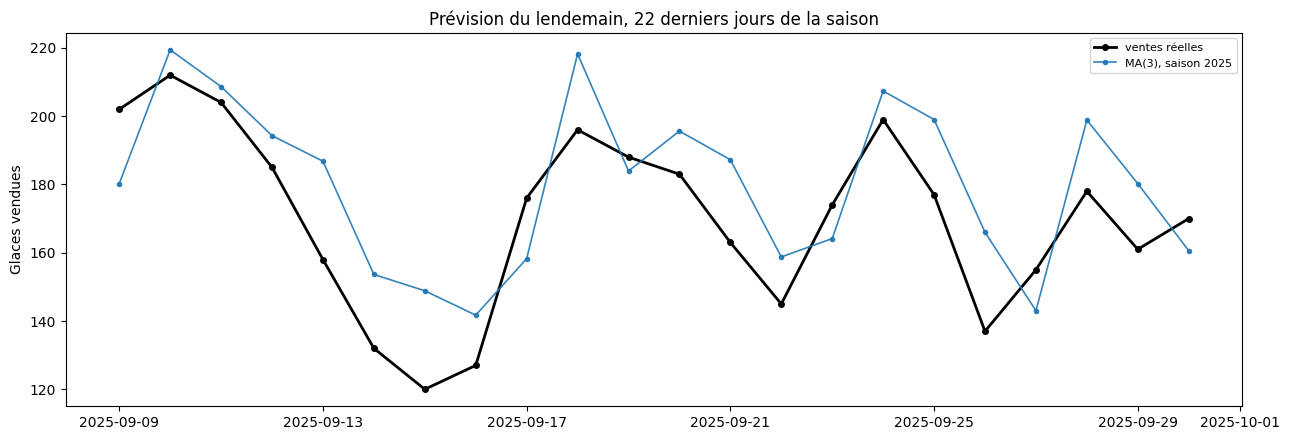

In [21]:
prev_ma_2025 = prevision_1_jour(resultat_ma, ventes_2025, N_TEST)
scores["MA(3), saison 2025 seule"] = mae(test, prev_ma_2025)

display(tableau_des_scores(scores))
plot_previsions(dates_test, test, {"MA(3), saison 2025": prev_ma_2025},
                titre="Prévision du lendemain, 22 derniers jours de la saison")

Le MA(3) fait mieux que les deux réflexes de Bruno. C'est déjà une victoire : on a transformé un carnet à spirale en une prévision quantifiée, avec une barre d'erreur.

Mais quelque chose cloche.

# Partie 4 - Le carton du grenier : place à l'ARMA

Nous allons maintenant passer aux données des **trois étés précédents**. On passe ainsi de 122 jours à 488. Rejouons le corrélogramme sur l'ensemble.

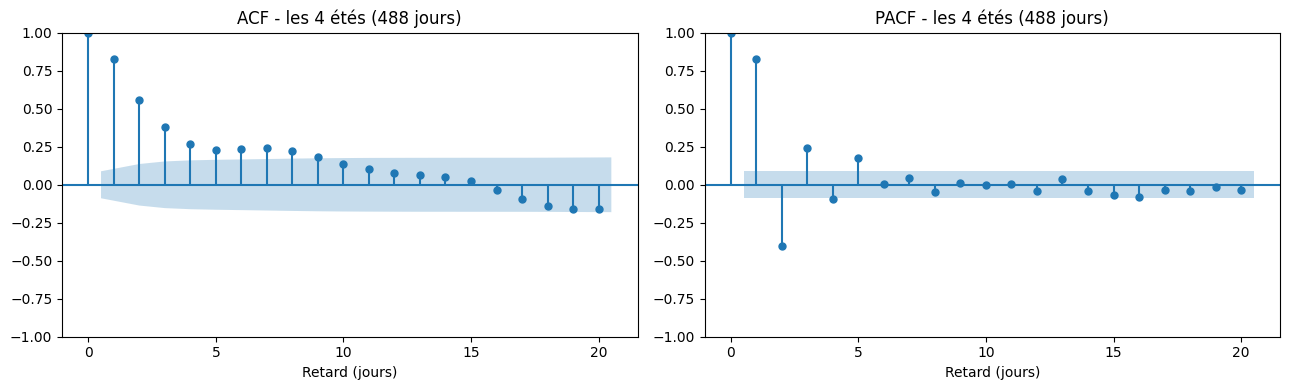

Autocorrélations, saison 2025 seule (122 jours) puis 4 étés (488 jours) :
  retard  1 : +0.813   vs   +0.828
  retard  2 : +0.518   vs   +0.559
  retard  3 : +0.319   vs   +0.378
  retard  5 : +0.081   vs   +0.231
  retard  7 : +0.077   vs   +0.243
  retard  9 : +0.103   vs   +0.181


In [22]:
plot_correlogrammes(ventes, lags=20, titre="- les 4 étés (488 jours)")

print("Autocorrélations, saison 2025 seule (122 jours) puis 4 étés (488 jours) :")
for lag in [1, 2, 3, 5, 7, 9]:
    print(f"  retard {lag:2d} : {autocorrelation(ventes_2025, lag):+.3f}   vs   {autocorrelation(ventes, lag):+.3f}")

Le verdict change complètement. Avec 122 jours, l'ACF semblait s'arrêter au retard 3... mais c'est parce qu'avec si peu de points, la bande d'incertitude est large et **noie tout ce qui est faible**. Avec 488 jours, on voit que la mémoire ne s'arrête pas : elle **décroît lentement**, et sort encore de la bande au retard 9.

Or on vient de le démontrer à l'Étape 2 : un MA(q) oublie tout brutalement après `q` jours. Pour couvrir une mémoire qui traîne jusqu'au retard 9, il faudrait un MA(9), c'est-à-dire neuf coefficients à estimer. Beaucoup, pour dire une chose simple.

C'est là qu'intervient la partie **AR**. Un seul coefficient $\phi$ suffit à produire une mémoire qui s'atténue indéfiniment, parce qu'elle se transmet de proche en proche :

$$y_t = \mu + \underbrace{\phi\,(y_{t-1} - \mu)}_{\text{AR : l'inertie}} + \underbrace{\varepsilon_t + \theta_1 \varepsilon_{t-1}}_{\text{MA : l'écho des surprises}}$$

Chaque jour hérite d'une fraction $\phi$ de l'écart de la veille, qui héritait lui-même de l'avant-veille : l'influence se propage en s'affaiblissant, sans jamais tomber d'un coup à zéro. C'est le modèle **ARMA(1,1)** : deux coefficients seulement.

### Étape 4 : le modèle ARMA

Même syntaxe qu'à l'Étape 3, avec cette fois un terme AR : `order=(1, 0, 1)`. Entraîne-le sur `train`, l'historique complet privé des 22 derniers jours.

In [24]:
### START CODE HERE ###

resultat_arma = ARIMA(train, order=(1, 0, 1), trend="c").fit()  # ARMA(1,1) : 1 terme AR, 1 terme MA

### END CODE HERE ###

print(f"mu  : {resultat_arma.params[0]:.1f} glaces par jour")
print(f"phi : {resultat_arma.params[1]:+.3f}   <- l'inertie (AR)")
print(f"theta : {resultat_arma.params[2]:+.3f}   <- l'écho des surprises (MA)")

resultat_ma_complet = ARIMA(train, order=(0, 0, 3), trend="c").fit()   # le MA(3), réentraîné sur tout l'historique
print(f"\nAIC MA(3)     : {resultat_ma_complet.aic:.1f}  ({len(resultat_ma_complet.params) - 2} coefficients)")
print(f"AIC ARMA(1,1) : {resultat_arma.aic:.1f}  ({len(resultat_arma.params) - 2} coefficients)")

assert resultat_arma.aic < resultat_ma_complet.aic, \
    "L'ARMA devrait obtenir un meilleur AIC (plus bas) que le MA(3)"
print("\nExercice validé ! Moins de coefficients, et pourtant un meilleur score.")

mu  : 198.3 glaces par jour
phi : +0.675   <- l'inertie (AR)
theta : +0.632   <- l'écho des surprises (MA)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'



AIC MA(3)     : 3945.3  (3 coefficients)
AIC ARMA(1,1) : 3920.1  (2 coefficients)

Exercice validé ! Moins de coefficients, et pourtant un meilleur score.


L'**AIC** récompense les modèles qui expliquent bien les données *sans* multiplier les coefficients : plus il est bas, mieux c'est. L'ARMA(1,1) gagne avec deux coefficients là où le MA(3) en utilise trois.

Deuxième argument, plus parlant encore : les **résidus**. Si un modèle a tout capté, ce qu'il n'explique pas doit être du bruit pur, sans aucune structure restante. Le test de Ljung-Box répond par une p-value : au-dessus de 0.05, les résidus sont du bruit ; en dessous, il reste de l'information sur la table.

In [25]:
for nom, resultat in [("MA(3)", resultat_ma_complet), ("ARMA(1,1)", resultat_arma)]:
    p = acorr_ljungbox(resultat.resid, lags=[10], return_df=True)["lb_pvalue"].iloc[0]
    verdict = "bruit pur, rien oublié" if p > 0.05 else "il reste de la structure non captée !"
    print(f"{nom:10s} Ljung-Box p = {p:.3f}   -> {verdict}")

MA(3)      Ljung-Box p = 0.000   -> il reste de la structure non captée !
ARMA(1,1)  Ljung-Box p = 0.590   -> bruit pur, rien oublié


Sans appel : le MA(3) laisse de la structure derrière lui, l'ARMA(1,1) ne laisse que du bruit. Voyons enfin ce que ça donne sur les bacs à préparer.

,modèle,erreur moyenne (glaces/jour)
0,"ARMA(1,1), 4 étés",14.80
1,"MA(3), 4 étés",16.27
2,"MA(3), saison 2025 seule",16.48
3,Comme hier,19.00
4,Toujours la moyenne,30.38


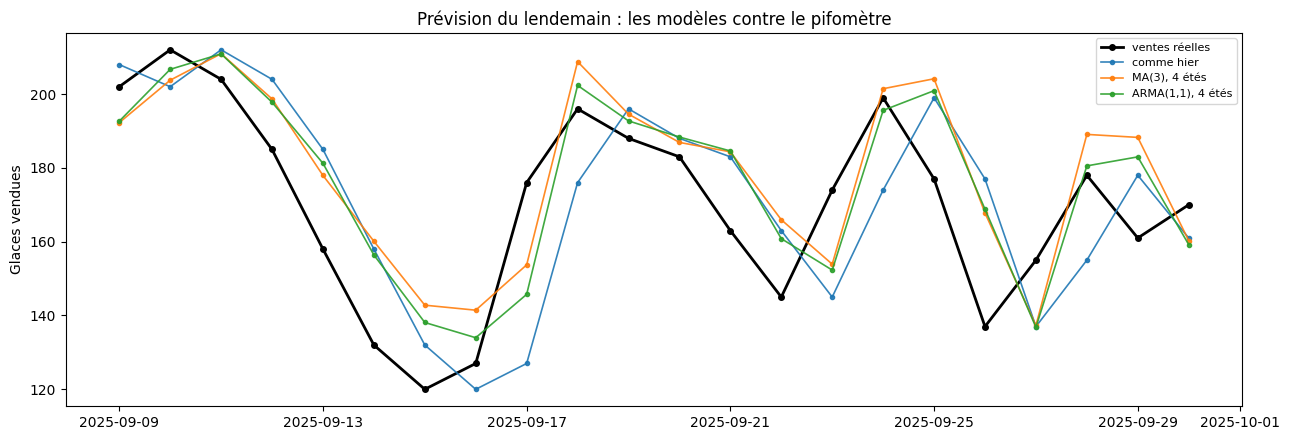

In [26]:
scores["MA(3), 4 étés"] = mae(test, prevision_1_jour(resultat_ma_complet, ventes, N_TEST))
scores["ARMA(1,1), 4 étés"] = mae(test, prevision_1_jour(resultat_arma, ventes, N_TEST))

display(tableau_des_scores(scores))

plot_previsions(dates_test, test,
                {"comme hier": baseline_hier,
                 "MA(3), 4 étés": prevision_1_jour(resultat_ma_complet, ventes, N_TEST),
                 "ARMA(1,1), 4 étés": prevision_1_jour(resultat_arma, ventes, N_TEST)},
                titre="Prévision du lendemain : les modèles contre le pifomètre")

# Partie 5 - La semaine de Bruno

Bruno ne commande pas que pour demain : son grossiste livre une fois par semaine. Il lui faut sept jours d'avance.

### Étape 5 : prévoir les 7 prochains jours

`get_forecast(steps=7)` demande à un modèle ajusté de prolonger la série de 7 jours. Son attribut `.predicted_mean` contient les valeurs prévues.

Fais-le pour les deux modèles, le MA(3) et l'ARMA(1,1), et compare.

In [28]:
### START CODE HERE ###

semaine_ma = resultat_ma_complet.get_forecast(steps=7).predicted_mean # (1) le MA(3)
semaine_arma = resultat_arma.get_forecast(steps=7).predicted_mean # (2) l'ARMA(1,1)

### END CODE HERE ###

print("jour :  ", "  ".join(f"J+{j}" for j in range(1, 8)))
print("MA(3):  ", "  ".join(f"{v:5.1f}" for v in semaine_ma))
print("ARMA :  ", "  ".join(f"{v:5.1f}" for v in semaine_arma))
print(f"\nmoyenne historique : {train.mean():.1f}")

assert len(semaine_ma) == 7 and len(semaine_arma) == 7, "On attend 7 valeurs, une par jour"
assert abs(semaine_ma[3] - semaine_ma[6]) < 0.01, \
    "Le MA(3) devrait donner exactement la même valeur du 4e au 7e jour"
assert abs(semaine_arma[3] - semaine_arma[6]) > 0.01, "L'ARMA, lui, continue d'évoluer"
print("Exercice validé !")

jour :   J+1  J+2  J+3  J+4  J+5  J+6  J+7
MA(3):   192.3  191.3  192.9  198.3  198.3  198.3  198.3
ARMA :   192.7  194.5  195.7  196.6  197.1  197.5  197.8

moyenne historique : 198.3
Exercice validé !


Regarde bien les deux lignes de chiffres. À partir du **quatrième jour**, le MA(3) répond exactement la moyenne, et ne bouge plus d'un pouce : sa mémoire fait trois jours, au-delà il n'a plus rien à dire. L'ARMA, lui, revient vers la moyenne **progressivement** — il sait encore que la semaine a mal commencé.

C'est toute la valeur du terme AR, et ça se voit à l'oeil nu sur le graphique.

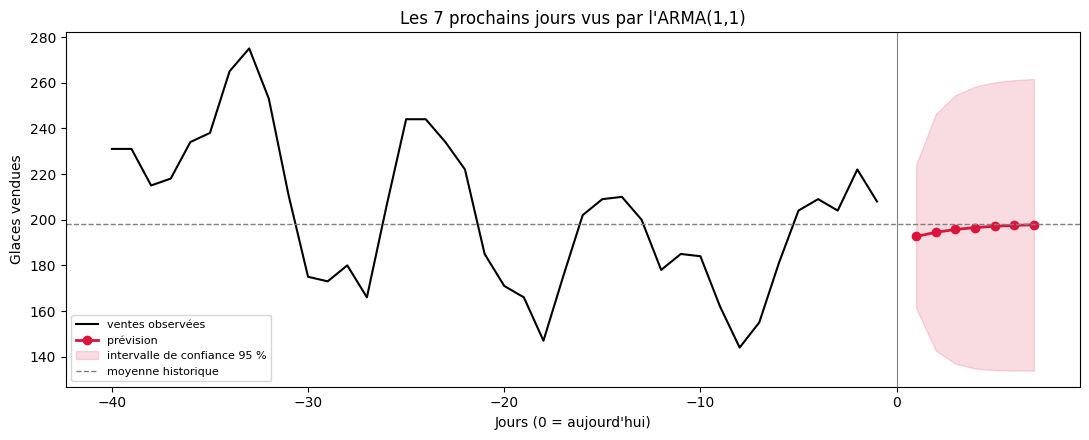

In [29]:
plot_semaine(train, resultat_arma, steps=7, titre="Les 7 prochains jours vus par l'ARMA(1,1)")

L'intervalle de confiance mérite un instant d'attention. Pour demain, le modèle annonce une fourchette d'environ 160 à 225 glaces. Au septième jour, elle s'élargit à 135-260, c'est-à-dire à peu près... la fourchette de n'importe quel jour d'été.

C'est le message honnête à faire passer à Bruno : **prévoir la veille pour le lendemain, ça marche ; prévoir à une semaine, non**. Pour la commande hebdomadaire, il peut se fier à la moyenne. Pour sortir les bacs du congélateur chaque matin, il a maintenant un vrai outil.

----
# Bilan

## Tu dégustes ta Glace bien méritée, et puis...

...Et puis trois portières claquent.

Une voiture s'est arrêtée sur  la plage. Léa en descend la première, téléphone à la main. Derrière elle, Marc, le même costume froissé que le jour où il t'a appelé pour son hôtel. Et un troisième homme que tu n'as pas revu depuis le tout début des vacances : le directeur de l'aéroport, celui dont tu avais épluché la base de réservations avec ton premier café de juillet.

Ils traversent le sable en chaussures de ville. Ça ne présage rien de bon.

Chacun te tend une clef USB...


<div align="center">
<img src="./teasing07.png" alt="ouvrir dans VSCode pour voir l'image" width="800"/>
</div>

Léa : « On te cherche depuis ce matin »

Marc : « Ce que tu m'as construit pour l'hôtel. Il faudrait le refaire. En beaucoup plus grand. Et il faudrait que n'importe qui puisse s'en servir... pas seulement toi, devant ton ordinateur. »

Le directeur pose sa clé USB sur le comptoir de Bruno. « Tout est là-dedans. On a chacun un morceau. Mais aucun de nous ne sait quoi en faire. »

Tu les regardes. Un aéroport. Un hôtel. Cent vingt villages.

Et toi au milieu, avec six semaines de projets dans les jambes.

« C'est urgent ? »

Les trois répondent en même temps. « C'est urgent. »

Léa retourne vers la voiture et ouvre déjà la portière arrière.

« C'est le plus gros projet de l'été. Sans doute celui qui nous servira le plus. Monte. »

Tu regardes ta glace, à moitié entamée. Bruno hausse les épaules et te la reprend des mains.

« Vas-y. Je te la garde au frais. »

Tu montes. La portière claque. La voiture repart le long de la mer.

Et tu n'as toujours aucune idée de ce qu'ils vont te demander.

Rendez-vous dimanche prochain.


---

# Bilan (le vrai)

Résumons les points clés de ce projet :

1. **Une série temporelle n'est pas un tableau de lignes indépendantes.** On ne mélange jamais avant de découper : le test doit être *après* l'entraînement, sinon on lit l'avenir.
2. **L'autocorrélation est le point de départ.** Tu l'as codée en trois lignes, et c'est elle qui a choisi le modèle : une ACF qui s'arrête net après `q` retards annonce un MA(q), une ACF qui décroît lentement réclame un terme AR.
3. **Le MA modélise l'écho des surprises** ($\varepsilon$), pas les valeurs passées. Sa mémoire s'arrête brutalement après `q` jours, et ça se voit sur la prévision à 7 jours qui devient plate.
4. **L'ARMA ajoute l'inertie**, et couvre avec deux coefficients une mémoire qu'un MA aurait dû payer neuf. Meilleur AIC, résidus enfin blancs, meilleure prévision.
5. **Peu de données mentent.** Sur 122 jours, l'ACF affirmait une mémoire de 3 jours. Sur 488, la même série en montrait une bien plus longue. La conclusion n'a pas changé parce que les données ont changé, mais parce qu'on en avait enfin assez pour voir juste.



### Pour aller plus loin

Quelques idées à explorer :

- ajouter la **saisonnalité hebdomadaire** que j'ai volontairement retirée : une vraie cabane de plage vend plus le week-end. C'est le modèle **SARIMA**, et `statsmodels` le gère avec un argument `seasonal_order=(P, D, Q, 7)`
- ajouter la **température** comme variable explicative : c'est le `exog=` de `SARIMAX`, et sur des glaces le gain devrait être spectaculaire
- essayer une série **non stationnaire** (un chiffre d'affaires qui grimpe d'année en année) et découvrir le `d` de l'ARIMA, la différenciation
- comparer avec un `HistGradientBoostingRegressor` de `scikit-learn` nourri de variables calendaires et de retards (`ventes_j-1`, `ventes_j-7`), l'approche Machine Learning du même problème
- refaire tourner le tout sur une vraie série : comme les [données de consommation électrique](https://www.data.gouv.fr)